In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
data = pd.read_csv(r"C:\Users\Leo Samuel Gilbert\Downloads\Bird_Migration_Data_with_Origin.csv")
data.head()

,Bird_ID,Species,Region,Habitat,Weather_Condition,Migration_Reason,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,...,Migration_Interrupted,Interrupted_Reason,Tagged_By,Tag_Weight_g,Migration_Success,Recovery_Location_Known,Recovery_Time_days,Observation_Counts,Observation_Quality,Origin
0,B1000,Warbler,South America,Grassland,Stormy,Feeding,11.906566,-169.378251,30.377647,-21.366879,...,Yes,Storm,Researcher_A,27.0,Failed,No,102,56,Low,"11.906566441337574, -169.37825068830264"
1,B1001,Stork,North America,Grassland,Stormy,Breeding,62.301546,-111.475069,39.921092,47.963436,...,Yes,Injury,Researcher_C,14.2,Successful,Yes,118,61,Low,"62.301545854189925, -111.47506945435978"
2,B1002,Hawk,South America,Mountain,Stormy,Avoid Predators,87.861164,-78.727327,66.990980,19.448466,...,No,Lost Signal,Researcher_B,16.1,Failed,No,41,71,High,"87.86116387126651, -78.72732718179907"
3,B1003,Warbler,South America,Urban,Stormy,Climate Change,35.770590,153.104341,-49.003145,-157.868744,...,Yes,Lost Signal,Researcher_C,24.4,Successful,No,15,68,Low,"35.77058955392532, 153.1043405316318"
4,B1004,Crane,Europe,Urban,Windy,Avoid Predators,-21.611614,106.674824,11.681051,-115.022863,...,No,NaN,Researcher_B,25.8,Failed,Yes,73,67,Moderate,"-21.611614380025586, 106.67482429343966"


In [3]:
data.shape

(10000, 42)

In [4]:
data.columns


Index(['Bird_ID', 'Species', 'Region', 'Habitat', 'Weather_Condition',
       'Migration_Reason', 'Start_Latitude', 'Start_Longitude', 'End_Latitude',
       'End_Longitude', 'Flight_Distance_km', 'Flight_Duration_hours',
       'Average_Speed_kmph', 'Max_Altitude_m', 'Min_Altitude_m',
       'Temperature_C', 'Wind_Speed_kmph', 'Humidity_%', 'Pressure_hPa',
       'Visibility_km', 'Nesting_Success', 'Tag_Battery_Level_%',
       'Signal_Strength_dB', 'Migration_Start_Month', 'Migration_End_Month',
       'Rest_Stops', 'Predator_Sightings', 'Tag_Type', 'Migrated_in_Flock',
       'Flock_Size', 'Food_Supply_Level', 'Tracking_Quality',
       'Migration_Interrupted', 'Interrupted_Reason', 'Tagged_By',
       'Tag_Weight_g', 'Migration_Success', 'Recovery_Location_Known',
       'Recovery_Time_days', 'Observation_Counts', 'Observation_Quality',
       'Origin'],
      dtype='object')

In [5]:
data['Signal_Strength_dB']

0      -64.9
1      -68.0
2      -71.9
3      -70.2
4      -50.5
        ... 
9995   -82.1
9996   -86.0
9997   -65.9
9998   -52.6
9999   -66.0
Name: Signal_Strength_dB, Length: 10000, dtype: float64

## Data Cleaning

#### Dropping irrelevant columns 

In [6]:
data = data.drop(['Bird_ID','Tagged_By','Tag_Weight_g','Tag_Type','Signal_Strength_dB','Observation_Counts','Observation_Quality'],axis=1)

In [7]:
data.shape

(10000, 35)

## Handling Missing values 



In [8]:
print("Missing Values Before Cleaning:")
print(data.isnull().sum())

Missing Values Before Cleaning:
Species                       0
Region                        0
Habitat                       0
Weather_Condition             0
Migration_Reason              0
Start_Latitude                0
Start_Longitude               0
End_Latitude                  0
End_Longitude                 0
Flight_Distance_km            0
Flight_Duration_hours         0
Average_Speed_kmph            0
Max_Altitude_m                0
Min_Altitude_m                0
Temperature_C                 0
Wind_Speed_kmph               0
Humidity_%                    0
Pressure_hPa                  0
Visibility_km                 0
Nesting_Success               0
Tag_Battery_Level_%           0
Migration_Start_Month         0
Migration_End_Month           0
Rest_Stops                    0
Predator_Sightings            0
Migrated_in_Flock             0
Flock_Size                    0
Food_Supply_Level             0
Tracking_Quality              0
Migration_Interrupted         0
Interrup

In [9]:
#check for duplication
print(data.duplicated().sum())

0


In [10]:
# Z-Score Method for outlier detection 
from scipy import stats

# Selecting numeric columns only
numeric_cols = data.select_dtypes(include=[np.number]).columns

# Calculating Z-scores
z_scores = np.abs(stats.zscore(data[numeric_cols]))

# Outliers where z > 3
outliers_zscore = np.where(z_scores > 3)
print("Outliers detected using Z-score method:", len(outliers_zscore[0]))

# IQR Method
outliers_iqr = {}
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    outliers_iqr[col] = outliers.shape[0]

print("Outliers detected using IQR method per column:")
for col, count in outliers_iqr.items():
    print(f"{col}: {count}")


Outliers detected using Z-score method: 94
Outliers detected using IQR method per column:
Start_Latitude: 0
Start_Longitude: 0
End_Latitude: 0
End_Longitude: 0
Flight_Distance_km: 74
Flight_Duration_hours: 71
Average_Speed_kmph: 86
Max_Altitude_m: 0
Min_Altitude_m: 0
Temperature_C: 0
Wind_Speed_kmph: 0
Humidity_%: 0
Pressure_hPa: 0
Visibility_km: 0
Tag_Battery_Level_%: 0
Rest_Stops: 0
Predator_Sightings: 0
Flock_Size: 0
Recovery_Time_days: 0


## DATA TYPE CONVERSIONS

In [11]:
print("Before Conversion:\n", data.dtypes)


Before Conversion:
 Species                     object
Region                      object
Habitat                     object
Weather_Condition           object
Migration_Reason            object
Start_Latitude             float64
Start_Longitude            float64
End_Latitude               float64
End_Longitude              float64
Flight_Distance_km         float64
Flight_Duration_hours      float64
Average_Speed_kmph         float64
Max_Altitude_m               int64
Min_Altitude_m               int64
Temperature_C              float64
Wind_Speed_kmph            float64
Humidity_%                   int64
Pressure_hPa               float64
Visibility_km              float64
Nesting_Success             object
Tag_Battery_Level_%          int64
Migration_Start_Month       object
Migration_End_Month         object
Rest_Stops                   int64
Predator_Sightings           int64
Migrated_in_Flock           object
Flock_Size                   int64
Food_Supply_Level           object


In [12]:
# Convert categorical columns to 'category' type
categorical_cols = ['Species', 'Region', 'Habitat', 'Weather_Condition', 
                    'Migration_Reason', 'Nesting_Success', 
                    'Migration_Start_Month', 'Migration_End_Month', 
                     'Origin']

for col in categorical_cols:
    data[col] = data[col].astype('category')


print(data.dtypes)


Species                    category
Region                     category
Habitat                    category
Weather_Condition          category
Migration_Reason           category
Start_Latitude              float64
Start_Longitude             float64
End_Latitude                float64
End_Longitude               float64
Flight_Distance_km          float64
Flight_Duration_hours       float64
Average_Speed_kmph          float64
Max_Altitude_m                int64
Min_Altitude_m                int64
Temperature_C               float64
Wind_Speed_kmph             float64
Humidity_%                    int64
Pressure_hPa                float64
Visibility_km               float64
Nesting_Success            category
Tag_Battery_Level_%           int64
Migration_Start_Month      category
Migration_End_Month        category
Rest_Stops                    int64
Predator_Sightings            int64
Migrated_in_Flock            object
Flock_Size                    int64
Food_Supply_Level           

In [13]:
data['Migration_End_Month'].value_counts()

Migration_End_Month
Nov    1474
Apr    1461
Mar    1442
Dec    1438
Jun    1408
Oct    1393
May    1384
Name: count, dtype: int64

## Encoding 

In [14]:
#mapping successful to 1 and failed to 0 
data['Migration_Success'] = data['Migration_Success'].map({'Successful': 1, 'Failed': 0})


print(data['Migration_Success'].value_counts())


Migration_Success
1    5094
0    4906
Name: count, dtype: int64


In [15]:
food_map = {'Low': 1, 'Medium': 2, 'High': 3}
data['Food_Supply_Num'] = data['Food_Supply_Level'].map(food_map)
data['Food_Supply_Num'].value_counts()


Food_Supply_Num
3    3412
1    3349
2    3239
Name: count, dtype: int64

In [16]:
# Create flock size bands using the intended ranges

def classify_flock_size(size):
    if size == 1:
        return 'Solo (1)'
    elif 2 <= size <= 5:
        return 'Small (2–5)'
    elif 6 <= size <= 15:
        return 'Medium (6–15)'
    elif 16 <= size <= 30:
        return 'Large (16–30)'
    elif size >= 31:
        return 'Very large (31+)'
    else:
        return np.nan

data['Flock_Size_Band'] = data['Flock_Size'].apply(classify_flock_size)

In [17]:
flock_map = {
    'Solo (1)': 1,
    'Small (2–5)': 2,
    'Medium (6–15)': 3,
    'Large (16–30)': 4,
    'Very large (31+)': 5
}

data['Flock_Size_Num'] = data['Flock_Size_Band'].map(flock_map)

print(data['Flock_Size_Num'].value_counts().sort_index(ascending=False))

Flock_Size_Num
5    9344
4     343
3     207
2      90
1      16
Name: count, dtype: int64


In [18]:
print(data['Flock_Size_Band'].value_counts(dropna=False))

Flock_Size_Band
Very large (31+)    9344
Large (16–30)        343
Medium (6–15)        207
Small (2–5)           90
Solo (1)              16
Name: count, dtype: int64


## OUTLIER DETECTION

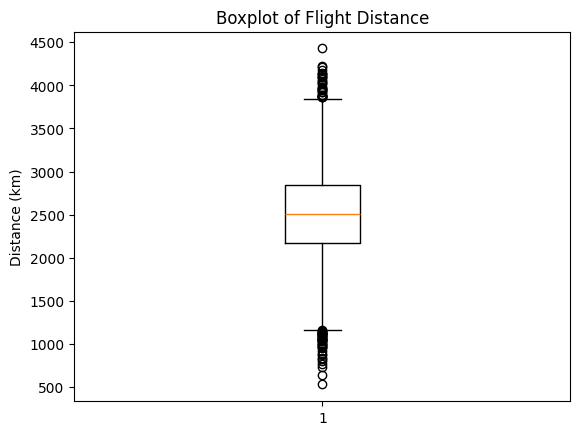

In [19]:
import matplotlib.pyplot as plt

plt.boxplot(data['Flight_Distance_km'])
plt.title("Boxplot of Flight Distance")
plt.ylabel("Distance (km)")
plt.show()


In [20]:
print("Minimum:", data['Flight_Distance_km'].min())
print("1st Percentile:", q_low)
print("99th Percentile:", q_high)
print("Maximum:", data['Flight_Distance_km'].max())


Minimum: 527.7


NameError: name 'q_low' is not defined

In [ ]:
outliers = data[(data['Flight_Distance_km'] < q_low) | (data['Flight_Distance_km'] > q_high)]
print("Number of Outliers:", outliers.shape[0])
print(outliers[['Bird_ID', 'Flight_Distance_km']].head(10))  # show first 10 outliers

Number of Outliers: 0
Empty DataFrame
Columns: [Bird_ID, Flight_Distance_km]
Index: []


In [ ]:
# Example: Cap Flight_Distance at 99th percentile
q_low, q_high = data['Flight_Distance_km'].quantile([0.01, 0.99])
data['Flight_Distance_km'] = np.where(data['Flight_Distance_km'] > q_high, q_high,
                                      np.where(data['Flight_Distance_km'] < q_low, q_low, data['Flight_Distance_km']))


## Automating outlier detection 

## Outlier detection

In [21]:
continuous_cols = [
    'Flight_Distance_km', 'Average_Speed_kmph', 'Max_Altitude_m',
    'Min_Altitude_m', 'Temperature_C', 'Wind_Speed_kmph',
    'Humidity_%', 'Pressure_hPa', 'Visibility_km'
]

outlier_summary = {}

for col in continuous_cols:
    q_low, q_high = data[col].quantile([0.01, 0.99])
    outliers = data[(data[col] < q_low) | (data[col] > q_high)]
    outlier_summary[col] = outliers.shape[0]

for col, count in outlier_summary.items():
    print(f"{col}: {count} outliers")



Flight_Distance_km: 200 outliers
Average_Speed_kmph: 200 outliers
Max_Altitude_m: 200 outliers
Min_Altitude_m: 184 outliers
Temperature_C: 169 outliers
Wind_Speed_kmph: 189 outliers
Humidity_%: 91 outliers
Pressure_hPa: 194 outliers
Visibility_km: 146 outliers


## Pivot 

In [22]:
features = list(data.columns)
print(features)

['Species', 'Region', 'Habitat', 'Weather_Condition', 'Migration_Reason', 'Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude', 'Flight_Distance_km', 'Flight_Duration_hours', 'Average_Speed_kmph', 'Max_Altitude_m', 'Min_Altitude_m', 'Temperature_C', 'Wind_Speed_kmph', 'Humidity_%', 'Pressure_hPa', 'Visibility_km', 'Nesting_Success', 'Tag_Battery_Level_%', 'Migration_Start_Month', 'Migration_End_Month', 'Rest_Stops', 'Predator_Sightings', 'Migrated_in_Flock', 'Flock_Size', 'Food_Supply_Level', 'Tracking_Quality', 'Migration_Interrupted', 'Interrupted_Reason', 'Migration_Success', 'Recovery_Location_Known', 'Recovery_Time_days', 'Origin', 'Food_Supply_Num', 'Flock_Size_Band', 'Flock_Size_Num']


In [23]:
for feature in features:
    pivot = data.pivot_table(index=feature,aggfunc='size')
    feature_pivot_table_df = pivot.reset_index(name='count')
    display(feature_pivot_table_df)


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_41760\4051670670.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = data.pivot_table(index=feature,aggfunc='size')


,Species,count
0,Crane,1391
1,Eagle,1426
2,Goose,1428
3,Hawk,1464
4,Stork,1439
5,Swallow,1423
6,Warbler,1429


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_41760\4051670670.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = data.pivot_table(index=feature,aggfunc='size')


,Region,count
0,Africa,1669
1,Asia,1687
2,Australia,1633
3,Europe,1595
4,North America,1699
5,South America,1717


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_41760\4051670670.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = data.pivot_table(index=feature,aggfunc='size')


...

C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_41760\4051670670.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = data.pivot_table(index=feature,aggfunc='size')


,Origin,count
0,"-0.0246360838085593, -44.481967874536",1
1,"-0.0278168786031329, 103.9061494769548",1
2,"-0.0303925434602376, 150.0753051290214",1
3,"-0.0412250952710451, -149.01441256523626",1
4,"-0.0568340430333904, 88.35464134507367",1
...,...,...
9995,"9.978655988207151, 130.58278577615113",1
9996,"9.981135408373731, -32.20259364074798",1
9997,"9.984037931796962, -167.55310595319563",1
9998,"9.990531275726354, 128.2780781926882",1


,Food_Supply_Num,count
0,1,3349
1,2,3239
2,3,3412


,Flock_Size_Band,count
0,Large (16–30),343
1,Medium (6–15),207
2,Small (2–5),90
3,Solo (1),16
4,Very large (31+),9344


,Flock_Size_Num,count
0,1,16
1,2,90
2,3,207
3,4,343
4,5,9344


## Binning 

In [24]:
#binning flight distance km to category 
bins = [0, 1000, 2000, 3000, float('inf')]
labels = ['Short', 'Medium', 'Long', 'Very Long']
data['Flight_Distance_Category'] = pd.cut(data['Flight_Distance_km'], bins=bins, labels=labels)

data['Flight_Distance_Category'].value_counts()


Flight_Distance_Category
Long         6857
Medium       1563
Very Long    1563
Short          17
Name: count, dtype: int64

In [25]:
speed_bins = [30.0, 40.0, 50.0, 60.0, 70.0,float('inf')]  # Bin edges
speed_labels = ['30-40 KMPH', '40-50 KMPH', '50-60 KMPH', '60-70 KMPH','70+ KMPH']
data['Speed_Category'] = pd.cut(data['Average_Speed_kmph'], bins=speed_bins, labels=speed_labels)

data['Speed_Category'].value_counts()

Speed_Category
50-60 KMPH    4785
40-50 KMPH    4708
30-40 KMPH     267
60-70 KMPH     240
70+ KMPH         0
Name: count, dtype: int64

In [26]:
altitude_bins = [0, 1000, 3000, 5000, float('inf')]
altitude_labels = ['Low', 'Medium', 'High', 'Very High']
data['Altitude_Category'] = pd.cut(data['Max_Altitude_m'], bins=altitude_bins, labels=altitude_labels)

data['Altitude_Category'].value_counts()

Altitude_Category
Very High    5616
Medium       2206
High         2174
Low             4
Name: count, dtype: int64

In [27]:
temp_bins = [-float('inf'), 0, 20, 35, float('inf')]
temp_labels = ['Cold', 'Moderate', 'Warm', 'Very Hot']
data['Temperature_Category'] = pd.cut(data['Temperature_C'], bins=temp_bins, labels=temp_labels)
data['Temperature_Category'].value_counts()


Temperature_Category
Moderate    4422
Warm        3347
Cold        2231
Very Hot       0
Name: count, dtype: int64

In [28]:
wind_bins = [0, 10, 30, 50, float('inf')]
wind_labels = ['Calm', 'Breezy', 'Windy', 'Very Windy']
data['Wind_Speed_Category'] = pd.cut(data['Wind_Speed_kmph'],bins=wind_bins,labels=wind_labels )
data['Wind_Speed_Category'].value_counts()

Wind_Speed_Category
Windy         3380
Breezy        3259
Very Windy    1707
Calm          1647
Name: count, dtype: int64

In [29]:
visibility_bins = [0, 5, 10, 20, float('inf')]
visibility_labels = ['Poor', 'Moderate', 'Good', 'Excellent']
data['Visibility_Category'] = pd.cut(data['Visibility_km'], bins=visibility_bins, labels=visibility_labels)
data['Visibility_Category'].value_counts()



Visibility_Category
Good         5357
Moderate     2566
Poor         2077
Excellent       0
Name: count, dtype: int64

In [30]:
humidity_bins = [0, 30, 60, 90, 100]
humidity_labels = ['Low', 'Moderate', 'High', 'Very High']
data['Humidity_Category'] = pd.cut(data['Humidity_%'], bins=humidity_bins, labels=humidity_labels)

data['Humidity_Category'].value_counts()

Humidity_Category
Moderate     3400
High         3301
Low          2344
Very High     955
Name: count, dtype: int64

In [31]:
bins   = [-np.inf, 1, 5, 15, 30, np.inf]
labels = ["Solo (1)", "Small (2–5)", "Medium (6–15)", "Large (16–30)", "Very large (31+)"]
data["Flock_Size_Band"] = pd.cut(data["Flock_Size"], bins=bins, labels=labels)

data["Flock_Size_Band"].value_counts()

Flock_Size_Band
Very large (31+)    9344
Large (16–30)        343
Medium (6–15)        207
Small (2–5)           90
Solo (1)              16
Name: count, dtype: int64

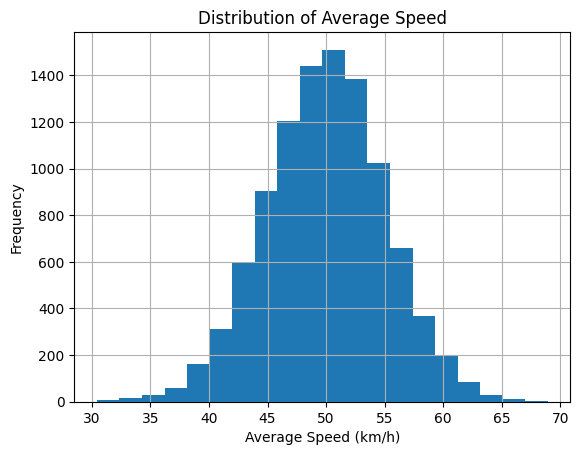

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns 
data['Average_Speed_kmph'].hist(bins=20)
plt.title('Distribution of Average Speed')
plt.xlabel('Average Speed (km/h)')
plt.ylabel('Frequency')
plt.show()

In [33]:
data['Species'].value_counts()

Species
Hawk       1464
Stork      1439
Warbler    1429
Goose      1428
Eagle      1426
Swallow    1423
Crane      1391
Name: count, dtype: int64

# EDA 

# Role of rest stops, predator sightings, flock size, food supply in migration success.

In [34]:
# Success rate by number of rest stops
success_by_rest = data.groupby("Rest_Stops")["Migration_Success"] \
                    .value_counts(normalize=True) \
                    .unstack()
print(success_by_rest)

Migration_Success         0         1
Rest_Stops                           
1                  0.486824  0.513176
2                  0.474761  0.525239
3                  0.466667  0.533333
4                  0.492497  0.507503
5                  0.447543  0.552457
6                  0.502104  0.497896
7                  0.485632  0.514368
8                  0.495702  0.504298
9                  0.462585  0.537415
10                 0.512126  0.487874
11                 0.523810  0.476190
12                 0.506006  0.493994
13                 0.505797  0.494203
14                 0.515988  0.484012


In [36]:
#visualisation 
success_by_rest[[ 'Successful', 'Failed']].plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['green','red']
)

plt.title("Migration Success Rate vs Rest Stops")
plt.xlabel("Rest Stops")
plt.ylabel("Proportion")
plt.legend(title="Migration Outcome")
plt.show()

KeyError: "None of [Index(['Successful', 'Failed'], dtype='object', name='Migration_Success')] are in the [columns]"

In [37]:
# Check the current values and data type
print("Migration_Success data type:", data["Migration_Success"].dtype)
print("\nCurrent values:")
print(data["Migration_Success"].value_counts())

Migration_Success data type: int64

Current values:
Migration_Success
1    5094
0    4906
Name: count, dtype: int64


In [38]:
# Predator sightings impact
success_by_predators = (
    data.groupby("Predator_Sightings")["Migration_Success"]
    .value_counts(normalize=True)
    .unstack()
    )

print("Proportions using Pandas GroupBy:")
print(success_by_predators)

Proportions using Pandas GroupBy:
Migration_Success          0         1
Predator_Sightings                    
0                   0.518049  0.481951
1                   0.454637  0.545363
2                   0.488488  0.511512
3                   0.483673  0.516327
4                   0.495976  0.504024
5                   0.478218  0.521782
6                   0.484699  0.515301
7                   0.505941  0.494059
8                   0.498492  0.501508
9                   0.496945  0.503055


In [39]:
# Convert Migration_Success into numeric format
# Successful = 1, Failed = 0

if data["Migration_Success"].dtype == "object":
    data["Migration_Success_Num"] = data["Migration_Success"].map({
        "Successful": 1,
        "Failed": 0
    })
else:
    data["Migration_Success_Num"] = pd.to_numeric(
        data["Migration_Success"],
        errors="coerce"
    )

# Check the result
print("Encoded Migration Success:")
print(data["Migration_Success_Num"].value_counts())

Encoded Migration Success:
Migration_Success_Num
1    5094
0    4906
Name: count, dtype: int64


In [40]:
# Ensure Migration_Success is numeric
data["Migration_Success_Num"] = data["Migration_Success"].map({
    "Successful": 1,
    "Failed": 0
})

# If the column is already numeric, preserve those values
data["Migration_Success_Num"] = data["Migration_Success_Num"].fillna(
    pd.to_numeric(data["Migration_Success"], errors="coerce")
)

# Calculate success rate for each predator sighting count
success_rates_numpy = (
    data.groupby("Predator_Sightings")["Migration_Success_Num"]
    .mean()
)

print("Migration Success Rate by Predator Sightings:\n")

for predators, rate in success_rates_numpy.items():
    print(
        f"{predators} predator(s): "
        f"{rate:.4f} ({rate * 100:.2f}%)"
    )

Migration Success Rate by Predator Sightings:

0 predator(s): 0.4820 (48.20%)
1 predator(s): 0.5454 (54.54%)
2 predator(s): 0.5115 (51.15%)
3 predator(s): 0.5163 (51.63%)
4 predator(s): 0.5040 (50.40%)
5 predator(s): 0.5218 (52.18%)
6 predator(s): 0.5153 (51.53%)
7 predator(s): 0.4941 (49.41%)
8 predator(s): 0.5015 (50.15%)
9 predator(s): 0.5031 (50.31%)


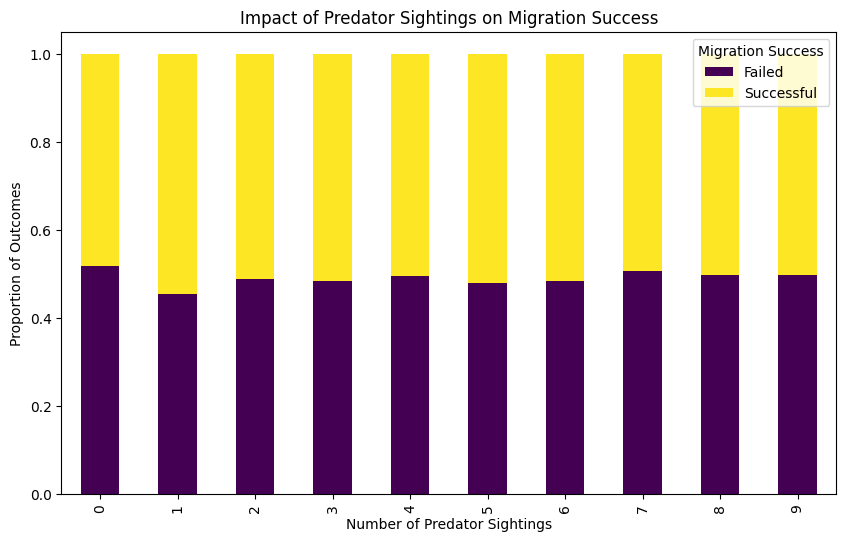

In [42]:
success_by_predators.plot(kind="bar", stacked=True, figsize=(10,6), colormap="viridis")
plt.title("Impact of Predator Sightings on Migration Success")
plt.xlabel("Number of Predator Sightings")
plt.ylabel("Proportion of Outcomes")
plt.legend(["Failed", "Successful"], title="Migration Success")
plt.show()

In [43]:
# Make sure Migration_Success is numeric
data["Migration_Success_Num"] = data["Migration_Success"].map({
    "Successful": 1,
    "Failed": 0
})

# If Migration_Success is already numeric, preserve those values
data["Migration_Success_Num"] = data["Migration_Success_Num"].fillna(
    pd.to_numeric(data["Migration_Success"], errors="coerce")
)

# Calculate success rate for each predator sighting count
predator_success = (
    data.groupby("Predator_Sightings")["Migration_Success_Num"]
    .mean()
    .sort_index()
)

# Display results
print("Migration Success Rate by Predator Sightings:\n")

for predator_count, success_rate in predator_success.items():
    print(
        f"{predator_count} predator(s): "
        f"{success_rate:.4f} "
        f"({success_rate * 100:.2f}%)"
    )

Migration Success Rate by Predator Sightings:

0 predator(s): 0.4820 (48.20%)
1 predator(s): 0.5454 (54.54%)
2 predator(s): 0.5115 (51.15%)
3 predator(s): 0.5163 (51.63%)
4 predator(s): 0.5040 (50.40%)
5 predator(s): 0.5218 (52.18%)
6 predator(s): 0.5153 (51.53%)
7 predator(s): 0.4941 (49.41%)
8 predator(s): 0.5015 (50.15%)
9 predator(s): 0.5031 (50.31%)


Does higher food supply level lead to better migration success?

In [44]:
food_props = (
    data.groupby("Food_Supply_Level")["Migration_Success"]
        .value_counts(normalize=True)
        .unstack()
        .fillna(0)
)
print("Pandas proportions by food supply level:\n", food_props)


Pandas proportions by food supply level:
 Migration_Success         0         1
Food_Supply_Level                    
High               0.491501  0.508499
Low                0.479248  0.520752
Medium             0.501389  0.498611


In [45]:
# Ensure Migration_Success is numerically encoded
data["Migration_Success_Num"] = data["Migration_Success"].map({
    "Successful": 1,
    "Failed": 0
})

# If the column is already numeric, preserve the numeric values
data["Migration_Success_Num"] = data["Migration_Success_Num"].fillna(
    pd.to_numeric(data["Migration_Success"], errors="coerce")
)

# Group by food supply level
food_groups = data.groupby("Food_Supply_Level")

# Calculate migration success rate using NumPy
food_rate_numpy = {}

for food_level, group in food_groups:
    success_rate = np.mean(
        group["Migration_Success_Num"].dropna().to_numpy()
    )
    
    food_rate_numpy[f"Food Supply = {food_level}"] = success_rate

# Display results
print("Success Rates using NumPy:\n")

for food_level, rate in food_rate_numpy.items():
    print(f"{food_level}: {rate:.4f} ({rate * 100:.2f}%)")

Success Rates using NumPy:

Food Supply = High: 0.5085 (50.85%)
Food Supply = Low: 0.5208 (52.08%)
Food Supply = Medium: 0.4986 (49.86%)


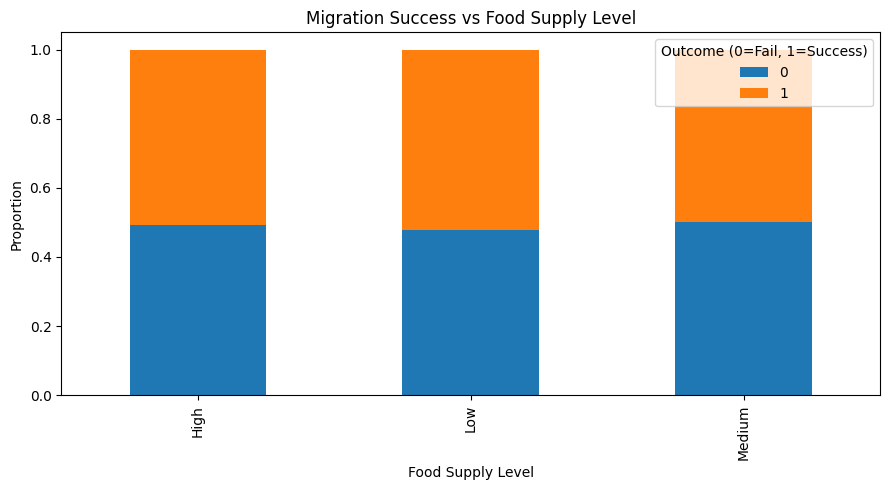

In [46]:
# Visualization - Stacked bar chart
food_props.plot(kind="bar", stacked=True, figsize=(9,5))
plt.title("Migration Success vs Food Supply Level")
plt.xlabel("Food Supply Level")
plt.ylabel("Proportion")
plt.legend(title="Outcome (0=Fail, 1=Success)")
plt.tight_layout()
plt.show()

In [47]:
# Calculate migration success rate by food supply level
food_success_rate = (
    data.groupby("Food_Supply_Level")["Migration_Success_Num"]
    .mean()
    .sort_index()
)

# Display results
print("Migration Success Rate by Food Supply Level:\n")

for food_level, rate in food_success_rate.items():
    print(f"{food_level}: {rate:.4f} ({rate * 100:.2f}%)")

Migration Success Rate by Food Supply Level:

High: 0.5085 (50.85%)
Low: 0.5208 (52.08%)
Medium: 0.4986 (49.86%)


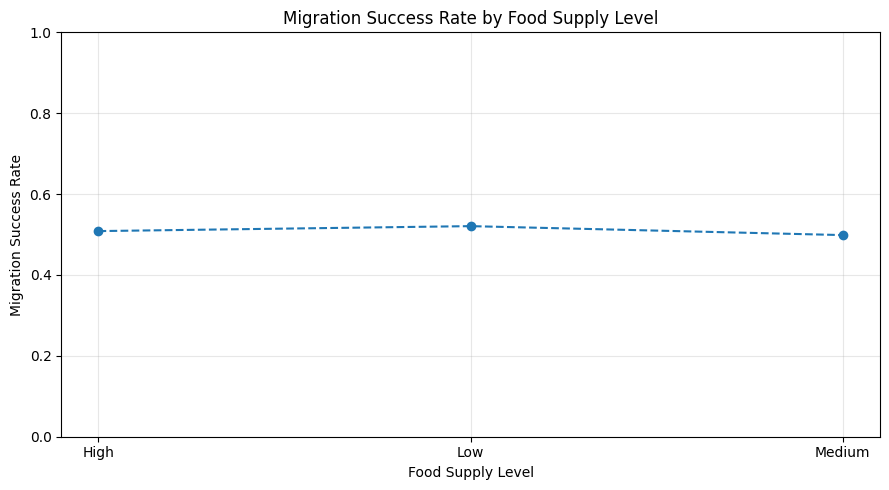

In [48]:
# Plot migration success rate by food supply level

plt.figure(figsize=(9, 5))

plt.plot(
    food_success_rate.index.astype(str),
    food_success_rate.to_numpy(),
    marker="o",
    linestyle="--"
)

plt.title("Migration Success Rate by Food Supply Level")
plt.xlabel("Food Supply Level")
plt.ylabel("Migration Success Rate")

plt.ylim(0, 1)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Does flock size increase the chance of migration success?

In [49]:
flock_props = (
    data.groupby("Flock_Size_Band")["Migration_Success"]
        .value_counts(normalize=True)
        .unstack()
        
)

print("Pandas proportions by flock-size band:\n", flock_props)


Pandas proportions by flock-size band:
 Migration_Success         0         1
Flock_Size_Band                      
Solo (1)           0.562500  0.437500
Small (2–5)        0.477778  0.522222
Medium (6–15)      0.478261  0.521739
Large (16–30)      0.448980  0.551020
Very large (31+)   0.492402  0.507598


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_41760\2429270747.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("Flock_Size_Band")["Migration_Success"]


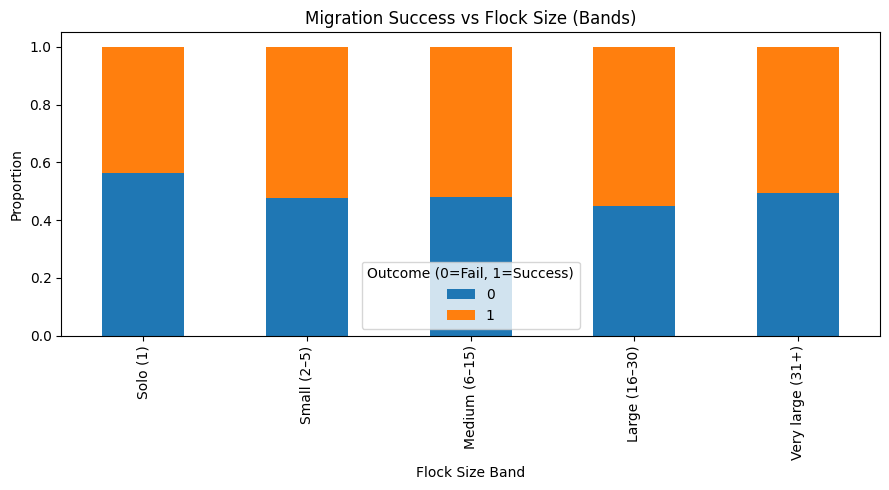

In [50]:
#visualisation - stacked chart 

flock_props.plot(kind="bar", stacked=True, figsize=(9,5))
plt.title("Migration Success vs Flock Size (Bands)")
plt.xlabel("Flock Size Band")
plt.ylabel("Proportion")
plt.legend(title="Outcome (0=Fail, 1=Success)")
plt.tight_layout()
plt.show()

Which factor among rest stops, predator sightings, flock size, and food supply has the strongest influence on migration success?

In [51]:
# Select numerical behavioral factors
factors = [
    'Rest_Stops',
    'Predator_Sightings',
    'Flock_Size',
    'Food_Supply_Num'
]

# Add encoded migration success
corr = data[factors + ['Migration_Success_Num']].corr()

print("Correlation between Behavioral Factors and Migration Success:")
print(corr)

Correlation between Behavioral Factors and Migration Success:
                       Rest_Stops  Predator_Sightings  Flock_Size  \
Rest_Stops               1.000000            0.001975    0.015299   
Predator_Sightings       0.001975            1.000000    0.012645   
Flock_Size               0.015299            0.012645    1.000000   
Food_Supply_Num          0.002601            0.000132   -0.011492   
Migration_Success_Num   -0.026734           -0.006273   -0.004159   

                       Food_Supply_Num  Migration_Success_Num  
Rest_Stops                    0.002601              -0.026734  
Predator_Sightings            0.000132              -0.006273  
Flock_Size                   -0.011492              -0.004159  
Food_Supply_Num               1.000000              -0.009997  
Migration_Success_Num        -0.009997               1.000000  


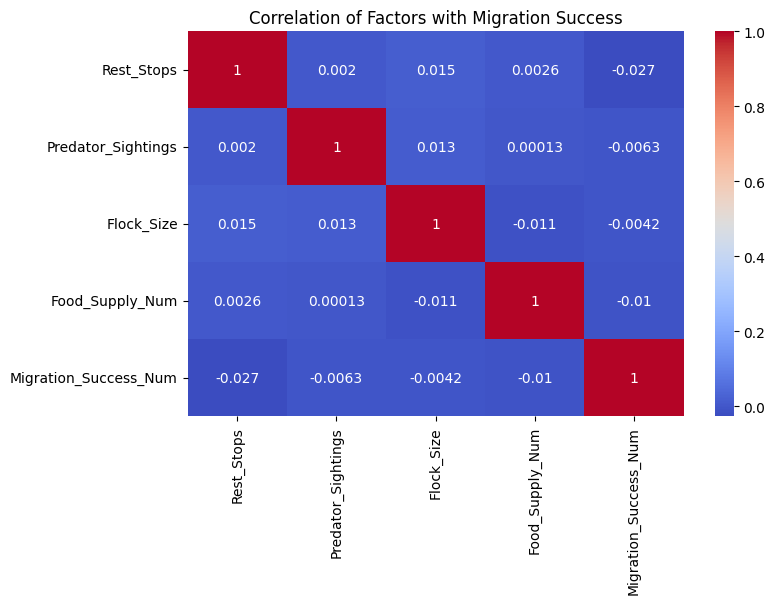

In [52]:
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation of Factors with Migration Success")
plt.show()

In [53]:
# Create interaction feature
data["Food_Flock_Interaction"] = (
    data["Food_Supply_Num"] * data["Flock_Size"]
)

# Calculate correlation with encoded migration success
interaction_corr = data[
    ["Food_Flock_Interaction", "Migration_Success_Num"]
].corr()

print("Correlation between Food-Flock Interaction and Migration Success:")
print(interaction_corr)

Correlation between Food-Flock Interaction and Migration Success:
                        Food_Flock_Interaction  Migration_Success_Num
Food_Flock_Interaction                1.000000              -0.010867
Migration_Success_Num                -0.010867               1.000000


In [54]:
# ============================================================
# ENSURE TARGET VARIABLE IS NUMERIC
# ============================================================

# Check current values
print("Migration_Success before encoding:")
print(data["Migration_Success"].value_counts())

# Convert target to numeric
data["Migration_Success"] = data["Migration_Success"].map({
    "Successful": 1,
    "Failed": 0
})

# Verify conversion
print("\nMigration_Success after encoding:")
print(data["Migration_Success"].value_counts())

print("\nData type:")
print(data["Migration_Success"].dtype)

Migration_Success before encoding:
Migration_Success
1    5094
0    4906
Name: count, dtype: int64

Migration_Success after encoding:
Series([], Name: count, dtype: int64)

Data type:
float64


In [55]:
#finding correlation 
factors = ['Food_Supply_Num','Flock_Size_Num','Rest_Stops','Predator_Sightings']
corr = data[factors + ['Migration_Success']].corr()

print(corr['Migration_Success'].sort_values(ascending=False))


Food_Supply_Num      NaN
Flock_Size_Num       NaN
Rest_Stops           NaN
Predator_Sightings   NaN
Migration_Success    NaN
Name: Migration_Success, dtype: float64


In [56]:
from scipy.stats import chi2_contingency

for col in ['Food_Supply_Level','Flock_Size_Band']:
    table = pd.crosstab(data[col], data['Migration_Success'])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"{col}: p-value = {p:.4f}")


ValueError: No data; `observed` has size 0.

### what are the common migration path for species

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# COMMON MIGRATION PATH ANALYSIS
# ============================================================

# Work only with the required columns
route_data = data[
    [
        "Species",
        "Start_Latitude",
        "Start_Longitude",
        "End_Latitude",
        "End_Longitude"
    ]
].copy()

# Round coordinates to reduce unnecessary precision
route_data["Start_Latitude"] = route_data["Start_Latitude"].round(2)
route_data["Start_Longitude"] = route_data["Start_Longitude"].round(2)
route_data["End_Latitude"] = route_data["End_Latitude"].round(2)
route_data["End_Longitude"] = route_data["End_Longitude"].round(2)

# Remove missing coordinate records
route_data = route_data.dropna()

# Group only observed combinations
path_counts = (
    route_data
    .groupby(
        [
            "Species",
            "Start_Latitude",
            "Start_Longitude",
            "End_Latitude",
            "End_Longitude"
        ],
        observed=True
    )
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

print("Top 10 Common Migration Paths:")
print(path_counts.head(10))

Top 10 Common Migration Paths:
      Species  Start_Latitude  Start_Longitude  End_Latitude  End_Longitude  \
9983  Warbler           87.49           -43.80         27.04          39.98   
9982  Warbler           87.35           -37.25         23.98        -163.68   
9981  Warbler           87.34            86.83        -66.84          74.13   
9980  Warbler           87.15           147.76         46.86         -36.42   
9979  Warbler           87.03           169.72         13.95          33.76   
9978  Warbler           87.03           -42.82         54.56        -134.03   
9977  Warbler           86.75           -96.46         52.40         137.29   
9976  Warbler           86.74           -24.80         45.88          29.49   
9975  Warbler           86.69           156.85        -39.99        -171.72   
9974  Warbler           86.66            40.31         18.76        -135.98   

      Count  
9983      1  
9982      1  
9981      1  
9980      1  
9979      1  
9978      1  
9

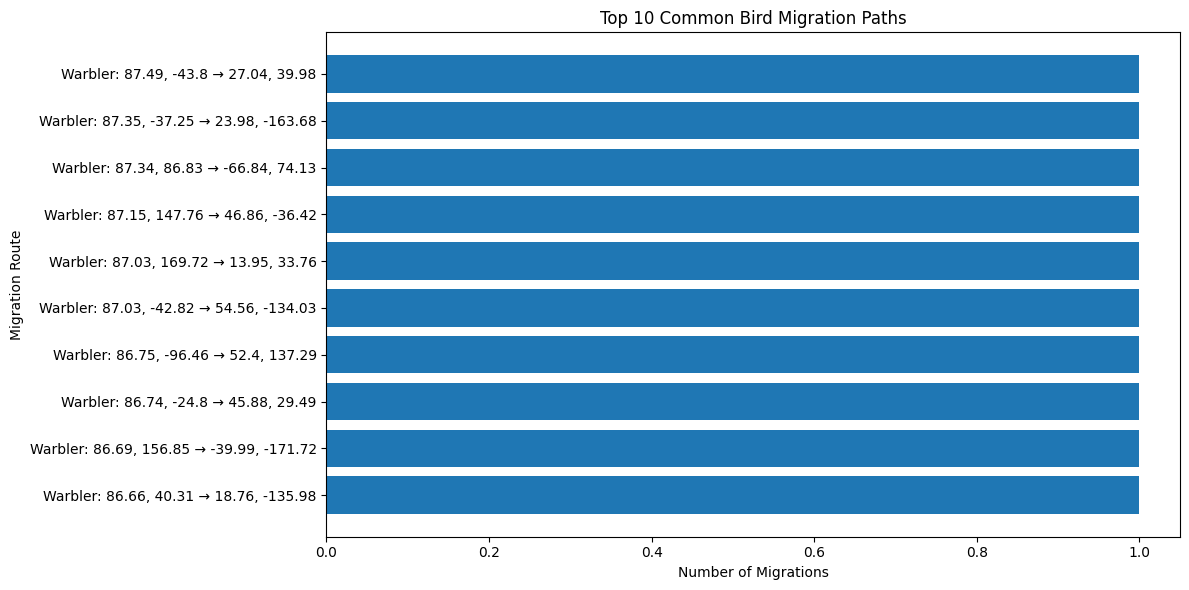

In [58]:
# ============================================================
# CREATE READABLE ROUTE LABELS
# ============================================================

top_paths = path_counts.head(10).copy()

top_paths["Path"] = (
    top_paths["Species"].astype(str)
    + ": "
    + top_paths["Start_Latitude"].astype(str)
    + ", "
    + top_paths["Start_Longitude"].astype(str)
    + " → "
    + top_paths["End_Latitude"].astype(str)
    + ", "
    + top_paths["End_Longitude"].astype(str)
)

# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 6))

plt.barh(
    top_paths["Path"].iloc[::-1],
    top_paths["Count"].iloc[::-1]
)

plt.title("Top 10 Common Bird Migration Paths")
plt.xlabel("Number of Migrations")
plt.ylabel("Migration Route")

plt.tight_layout()
plt.show()

In [59]:
data.columns

Index(['Species', 'Region', 'Habitat', 'Weather_Condition', 'Migration_Reason',
       'Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude',
       'Flight_Distance_km', 'Flight_Duration_hours', 'Average_Speed_kmph',
       'Max_Altitude_m', 'Min_Altitude_m', 'Temperature_C', 'Wind_Speed_kmph',
       'Humidity_%', 'Pressure_hPa', 'Visibility_km', 'Nesting_Success',
       'Tag_Battery_Level_%', 'Migration_Start_Month', 'Migration_End_Month',
       'Rest_Stops', 'Predator_Sightings', 'Migrated_in_Flock', 'Flock_Size',
       'Food_Supply_Level', 'Tracking_Quality', 'Migration_Interrupted',
       'Interrupted_Reason', 'Migration_Success', 'Recovery_Location_Known',
       'Recovery_Time_days', 'Origin', 'Food_Supply_Num', 'Flock_Size_Band',
       'Flock_Size_Num', 'Flight_Distance_Category', 'Speed_Category',
       'Altitude_Category', 'Temperature_Category', 'Wind_Speed_Category',
       'Visibility_Category', 'Humidity_Category', 'Migration_Success_Num',
       'Fo

In [60]:
# Create a 'Path' column combining start and end coordinates
data['Path'] = (
    data['Start_Latitude'].astype(str) + "," + data['Start_Longitude'].astype(str) +
    " → " +
    data['End_Latitude'].astype(str) + "," + data['End_Longitude'].astype(str)
)

# Count the frequency of each path per species
path_counts = (
    data.groupby(['Species', 'Path'])
    .size()
    .reset_index(name='Count')
)

# For each species, pick the most common migration path
most_common_paths = (
    path_counts.sort_values(['Species', 'Count'], ascending=[True, False])
    .groupby('Species')
    .head(1)
    .reset_index(drop=True)
)

print("Most common migration paths for each species:\n")
print(most_common_paths)


Most common migration paths for each species:

   Species                                               Path  Count
0    Crane  -0.0246360838085593,-44.481967874536 → 35.6544...      1
1    Eagle  -0.1684953119847421,58.543723472433726 → -61.2...      1
2    Goose  -0.0278168786031329,103.9061494769548 → 28.567...      1
3     Hawk  -0.0849987192715531,6.124966979750013 → -67.64...      1
4    Stork  -0.0303925434602376,150.0753051290214 → 74.805...      1
5  Swallow  -0.2072606287278517,-3.322434330900279 → 27.45...      1
6  Warbler  -0.1767899107874484,-128.4281264193197 → 24.11...      1


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_41760\2756840707.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(['Species', 'Path'])
C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_41760\2756840707.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Species')


In [61]:
data['Migration_Success'].value_counts()

Series([], Name: count, dtype: int64)

In [62]:
# Migration success by weather condition
weather_success = (
    data.groupby("Weather_Condition")["Migration_Success"]
    .mean()   # mean of 0/1 gives success rate
    .reset_index(name="Success_Rate")
    .sort_values(by="Success_Rate", ascending=False)
)

print("Success rates by weather condition:\n", weather_success)


Success rates by weather condition:
   Weather_Condition  Success_Rate
0             Clear           NaN
1             Foggy           NaN
2             Rainy           NaN
3            Stormy           NaN
4             Windy           NaN


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_41760\1831795762.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("Weather_Condition")["Migration_Success"]


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_41760\2138990158.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Weather_Condition", y="Success_Rate", data=weather_success, palette="coolwarm")


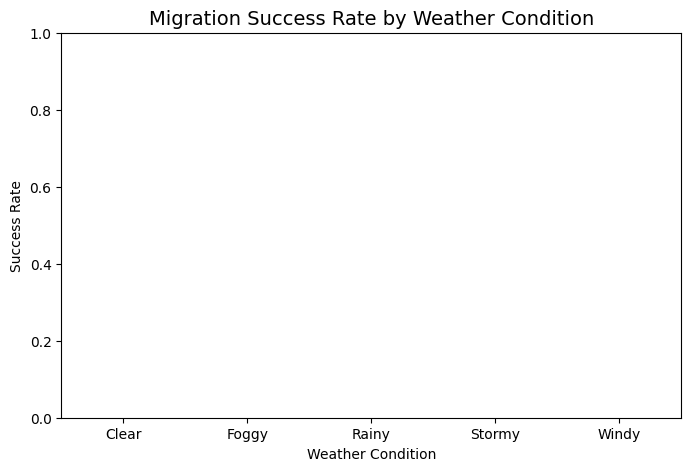

In [63]:
plt.figure(figsize=(8,5))
sns.barplot(x="Weather_Condition", y="Success_Rate", data=weather_success, palette="coolwarm")

plt.title("Migration Success Rate by Weather Condition", fontsize=14)
plt.ylabel("Success Rate")
plt.xlabel("Weather Condition")
plt.ylim(0,1)  # keep scale between 0 and 1
plt.show()

In [64]:
# ============================================================
# K-MEANS CLUSTERING: BIRD MIGRATION BEHAVIOR
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer


# ============================================================
# SELECT FEATURES FOR MIGRATION BEHAVIOR CLUSTERING
# ============================================================

features = [
    # Flight characteristics
    "Flight_Distance_km",
    "Flight_Duration_hours",
    "Average_Speed_kmph",
    "Max_Altitude_m",
    "Min_Altitude_m",

    # Environmental factors
    "Temperature_C",
    "Wind_Speed_kmph",
    "Humidity_%",
    "Pressure_hPa",
    "Visibility_km",

    # Behavioral factors
    "Rest_Stops",
    "Predator_Sightings",
    "Flock_Size"
]


# ============================================================
# CHECK THAT ALL FEATURES EXIST
# ============================================================

missing_features = [
    feature for feature in features
    if feature not in data.columns
]

if missing_features:
    print("Missing features:")
    print(missing_features)
else:
    print("All clustering features are available.")


# ============================================================
# PREPARE DATA
# ============================================================

migration_data = data[features].copy()

# Convert all selected features to numeric
migration_data = migration_data.apply(
    pd.to_numeric,
    errors="coerce"
)


# ============================================================
# HANDLE MISSING VALUES
# ============================================================

imputer = SimpleImputer(strategy="median")

imputed_data = imputer.fit_transform(
    migration_data
)


# ============================================================
# STANDARDIZE FEATURES
# ============================================================

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    imputed_data
)


# ============================================================
# APPLY K-MEANS CLUSTERING
# ============================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    scaled_data
)


# ============================================================
# ADD CLUSTERS TO ORIGINAL DATASET
# ============================================================

data["Migration_Behavior_Cluster"] = clusters


# ============================================================
# CLUSTER DISTRIBUTION
# ============================================================

print("\nMigration Behavior Cluster Distribution:")
print(
    data["Migration_Behavior_Cluster"]
    .value_counts()
    .sort_index()
)


# ============================================================
# CLUSTER BEHAVIOR SUMMARY
# ============================================================

cluster_summary = (
    data.groupby("Migration_Behavior_Cluster")[features]
    .mean(numeric_only=True)
)

print("\nCluster Behavior Summary:")
print(cluster_summary.round(2))

All clustering features are available.

Migration Behavior Cluster Distribution:
Migration_Behavior_Cluster
0    3232
1    3055
2    3713
Name: count, dtype: int64

Cluster Behavior Summary:
                            Flight_Distance_km  Flight_Duration_hours  \
Migration_Behavior_Cluster                                              
0                                      2452.67                  49.25   
1                                      2521.84                  51.54   
2                                      2534.10                  49.37   

                            Average_Speed_kmph  Max_Altitude_m  \
Migration_Behavior_Cluster                                       
0                                        50.20         5640.28   
1                                        49.72         5630.74   
2                                        49.93         5283.27   

                            Min_Altitude_m  Temperature_C  Wind_Speed_kmph  \
Migration_Behavior_Cluster        

In [65]:
# Count species within each cluster
species_cluster = (
    data.groupby(["Migration_Behavior_Cluster", "Species"])
    .size()
    .reset_index(name="Count")
    .sort_values(by=["Migration_Behavior_Cluster", "Count"], ascending=[True, False])
)

print(species_cluster)


    Migration_Behavior_Cluster  Species  Count
4                            0    Stork    481
5                            0  Swallow    474
0                            0    Crane    472
3                            0     Hawk    463
6                            0  Warbler    454
1                            0    Eagle    446
2                            0    Goose    442
11                           1    Stork    452
13                           1  Warbler    450
10                           1     Hawk    448
9                            1    Goose    441
7                            1    Crane    424
8                            1    Eagle    422
12                           1  Swallow    418
15                           2    Eagle    558
17                           2     Hawk    553
16                           2    Goose    545
19                           2  Swallow    531
20                           2  Warbler    525
18                           2    Stork    506
14           

C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_41760\2181673734.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["Migration_Behavior_Cluster", "Species"])


In [66]:
# Find dominant cluster for each species
dominant_cluster = (
    species_cluster.loc[
        species_cluster.groupby("Species")["Count"].idxmax()
    ].reset_index(drop=True)
)

print(dominant_cluster)


   Migration_Behavior_Cluster  Species  Count
0                           2    Crane    495
1                           2    Eagle    558
2                           2    Goose    545
3                           2     Hawk    553
4                           2    Stork    506
5                           2  Swallow    531
6                           2  Warbler    525


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_41760\1476570886.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  species_cluster.groupby("Species")["Count"].idxmax()


MIGRATION INTERRUPTED

In [67]:
data['Migration_Interrupted'].value_counts()

Migration_Interrupted
Yes    5031
No     4969
Name: count, dtype: int64

In [68]:
num_features = ["Flight_Distance_km", "Average_Speed_kmph", 
                "Max_Altitude_m", "Min_Altitude_m", 
                "Rest_Stops", "Food_Supply_Num"]

summary = data.groupby("Migration_Interrupted")[num_features].mean()
print("\nMean values by Migration_Interrupted:\n", summary)


Mean values by Migration_Interrupted:
                        Flight_Distance_km  Average_Speed_kmph  Max_Altitude_m  \
Migration_Interrupted                                                           
No                            2496.400320           49.958762     5544.955524   
Yes                           2511.577847           49.948092     5465.155834   

                       Min_Altitude_m  Rest_Stops  Food_Supply_Num  
Migration_Interrupted                                               
No                         503.162809    7.327229         2.020527  
Yes                        497.098390    7.432121         1.992248  


In [69]:
# Compare weather condition
weather_interrupt = (
    data.groupby(["Weather_Condition", "Migration_Interrupted"])
    .size()
    .unstack(fill_value=0)
)
print("\nWeather vs Migration Interrupted:\n", weather_interrupt)


Weather vs Migration Interrupted:
 Migration_Interrupted    No   Yes
Weather_Condition                
Clear                   956   969
Foggy                  1062  1074
Rainy                   957   963
Stormy                  999  1011
Windy                   995  1014


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_41760\2098942267.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["Weather_Condition", "Migration_Interrupted"])


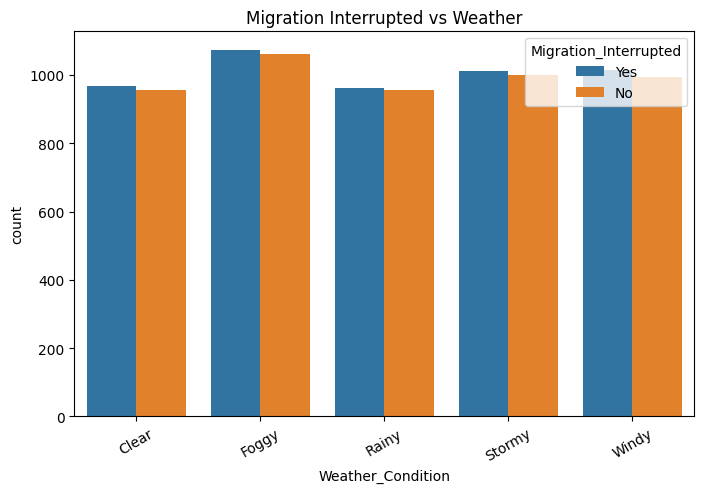

In [70]:
plt.figure(figsize=(8,5))
sns.countplot(x="Weather_Condition", hue="Migration_Interrupted", data=data)
plt.title("Migration Interrupted vs Weather")
plt.xticks(rotation=30)
plt.show()

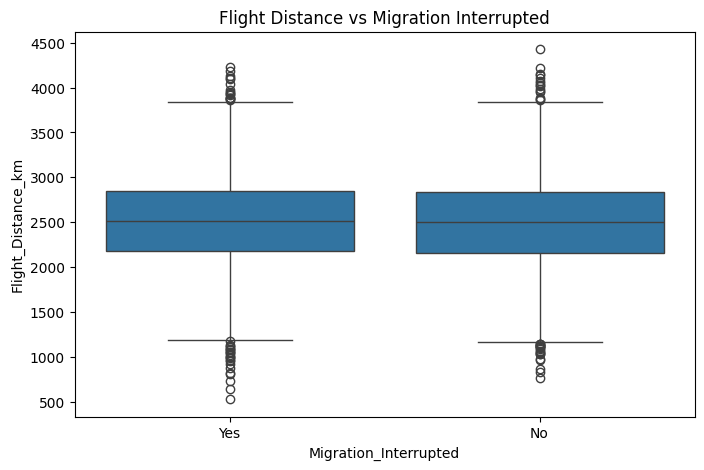

In [71]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Migration_Interrupted", y="Flight_Distance_km", data=data)
plt.title("Flight Distance vs Migration Interrupted")
plt.show()

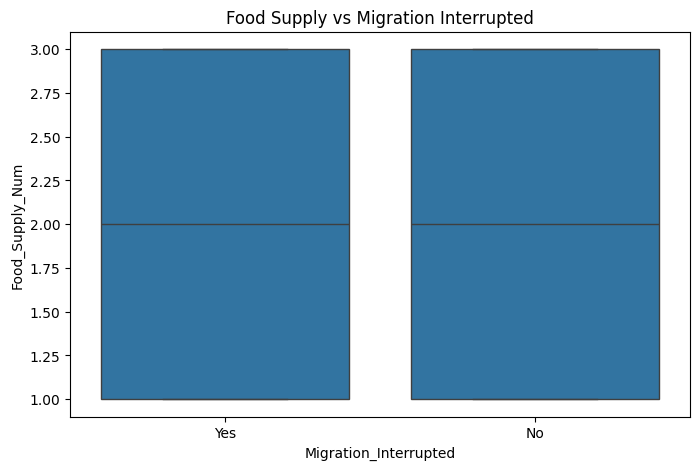

In [72]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Migration_Interrupted", y="Food_Supply_Num", data=data)
plt.title("Food Supply vs Migration Interrupted")
plt.show()

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure target variable is numeric 0/1
if data['Migration_Success'].dtype == 'O':
    data['Migration_Success'] = (
        data['Migration_Success'].str.strip().str.lower().map({'yes':1,'no':0})
    )

# Helpful z-score function (NumPy-only)
def zscore(a):
    a = np.asarray(a, dtype=float)
    mu = np.nanmean(a)
    sd = np.nanstd(a)
    return (a - mu) / (sd if sd > 0 else 1.0)


In [74]:
# --- Species-wise trends
species_stats = (data
    .groupby('Species', as_index=False)
    .agg(mean_distance_km=('Flight_Distance_km','mean'),
         mean_speed_kmph=('Average_Speed_kmph','mean'),
         success_rate=('Migration_Success','mean'),
         n=('Bird_ID','count'))
    .sort_values('mean_distance_km', ascending=False))
print(species_stats.head(10))

plt.figure()
plt.bar(species_stats['Species'], species_stats['mean_distance_km'])
plt.title("Mean Flight Distance by Species")
plt.ylabel("Mean Distance (km)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

# --- Region-wise success and effort
region_stats = (data
    .groupby('Region', as_index=False)
    .agg(success_rate=('Migration_Success','mean'),
         mean_distance_km=('Flight_Distance_km','mean'),
         n=('Bird_ID','count'))
    .sort_values('success_rate', ascending=False))
print(region_stats)

plt.figure()
plt.bar(region_stats['Region'], region_stats['success_rate'])
plt.title("Migration Success Rate by Region")
plt.ylabel("Success Rate")
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()




C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_41760\4062677604.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  species_stats = (data


KeyError: "Column(s) ['Bird_ID'] do not exist"

  Migration_Start_Month  count
0                   Apr   1215
1                   Feb   1252
2                   Jan   1273
3                   Mar   1297
4                   May   1239
5                   Nov   1273
6                   Oct   1262
7                   Sep   1189


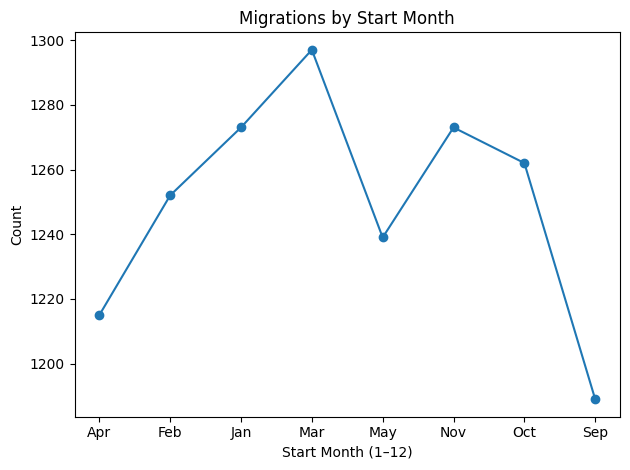

In [ ]:
#Seasonal patterns 
month_counts = (data
    .groupby('Migration_Start_Month', as_index=False)
    .size().rename(columns={'size':'count'})
    .sort_values('Migration_Start_Month'))
print(month_counts)

plt.figure()
plt.plot(month_counts['Migration_Start_Month'], month_counts['count'], marker='o')
plt.title("Migrations by Start Month")
plt.xlabel("Start Month (1–12)")
plt.ylabel("Count")
plt.tight_layout(); plt.show()

## Reasons for bird migrations 

In [76]:
reason_counts = data['Migration_Reason'].value_counts()

print("Overall Migration Reasons:\n")
print(reason_counts)

# comparing migration reason by species
reason_by_species = data.groupby(['Species', 'Migration_Reason']).size().unstack(fill_value=0)

print("\nMigration Reasons by Species:\n")
print(reason_by_species)



Overall Migration Reasons:

Migration_Reason
Feeding            2573
Avoid Predators    2518
Climate Change     2473
Breeding           2436
Name: count, dtype: int64

Migration Reasons by Species:

Migration_Reason  Avoid Predators  Breeding  Climate Change  Feeding
Species                                                             
Crane                         324       350             359      358
Eagle                         349       345             362      370
Goose                         390       310             348      380
Hawk                          371       335             390      368
Stork                         385       390             318      346
Swallow                       351       372             354      346
Warbler                       348       334             342      405


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_41760\2482431652.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reason_by_species = data.groupby(['Species', 'Migration_Reason']).size().unstack(fill_value=0)


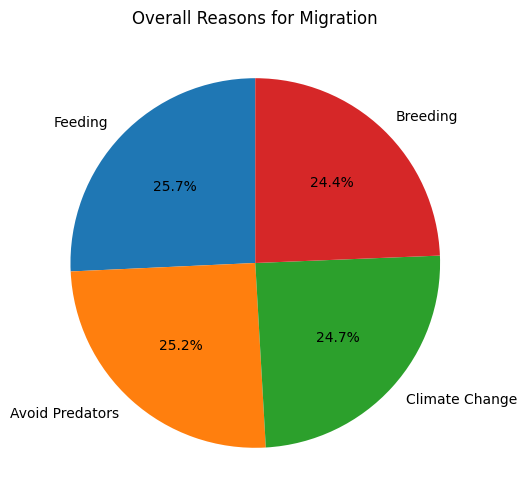

In [78]:
# Visualization - Pie chart for overall reasons
plt.figure(figsize=(6,6))
plt.pie(reason_counts, labels=reason_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Overall Reasons for Migration")
plt.show()

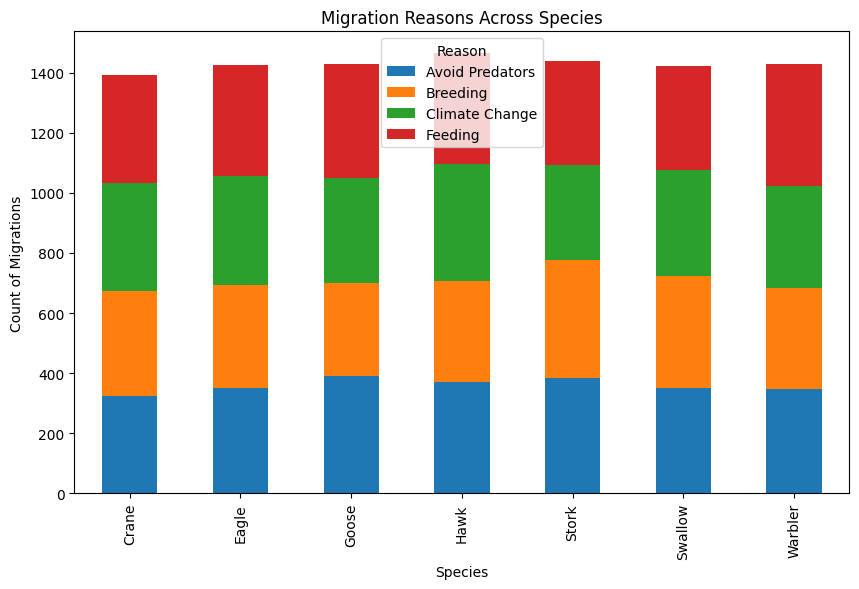

In [79]:
# Visualization - Bar chart by species
reason_by_species.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Migration Reasons Across Species")
plt.xlabel("Species")
plt.ylabel("Count of Migrations")
plt.legend(title="Reason")
plt.show()

In [81]:
df = data.copy()

C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_41760\1229877048.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  species_distance = df.groupby("Species")["Flight_Distance_km"].mean()


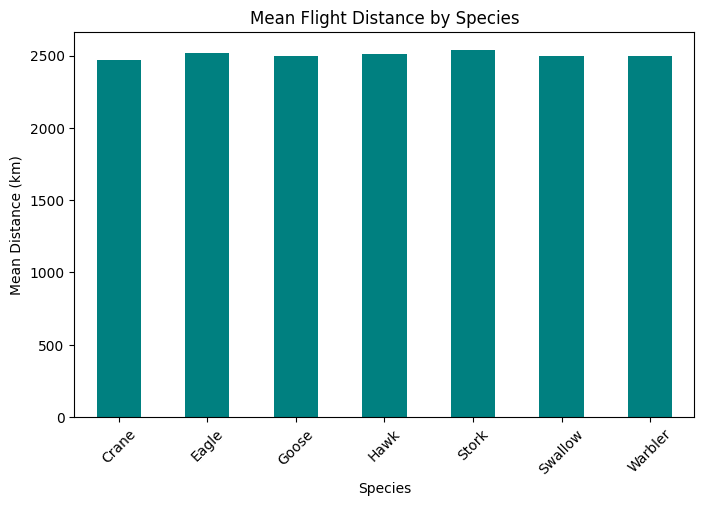

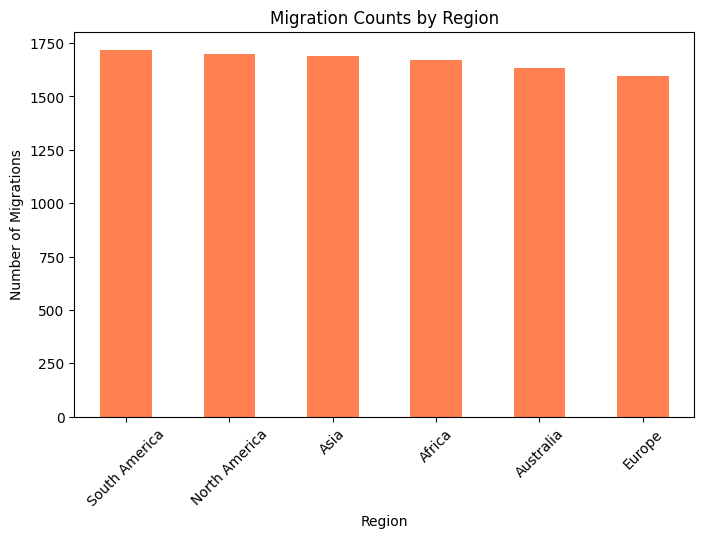

KeyError: 'Season'

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assuming your dataset is loaded as df
# Example: df = pd.read_csv("bird_migration.csv")

# 1. Mean Flight Distance by Species
species_distance = df.groupby("Species")["Flight_Distance_km"].mean()
species_distance.plot(kind="bar", figsize=(8,5), color="teal")
plt.ylabel("Mean Distance (km)")
plt.title("Mean Flight Distance by Species")
plt.xticks(rotation=45)
plt.show()

# 2. Migration Counts by Region
region_counts = df["Region"].value_counts()
region_counts.plot(kind="bar", figsize=(8,5), color="coral")
plt.ylabel("Number of Migrations")
plt.title("Migration Counts by Region")
plt.xticks(rotation=45)
plt.show()

# 3. Seasonal Migration Trends
season_distance = df.groupby("Season")["Flight_Distance_km"].mean()
season_distance.plot(kind="bar", figsize=(8,5), color="navy")
plt.ylabel("Mean Distance (km)")
plt.title("Seasonal Migration Trends")
plt.xticks(rotation=45)
plt.show()


## Weather and speed, 

In [83]:
weather_speed_corr = data[['Temperature_C', 'Wind_Speed_kmph', 'Humidity_%', 'Flight_Distance_km']].corr()
print(weather_speed_corr)

                    Temperature_C  Wind_Speed_kmph  Humidity_%  \
Temperature_C            1.000000         0.007708   -0.012315   
Wind_Speed_kmph          0.007708         1.000000   -0.014123   
Humidity_%              -0.012315        -0.014123    1.000000   
Flight_Distance_km      -0.000570        -0.017460   -0.001048   

                    Flight_Distance_km  
Temperature_C                -0.000570  
Wind_Speed_kmph              -0.017460  
Humidity_%                   -0.001048  
Flight_Distance_km            1.000000  


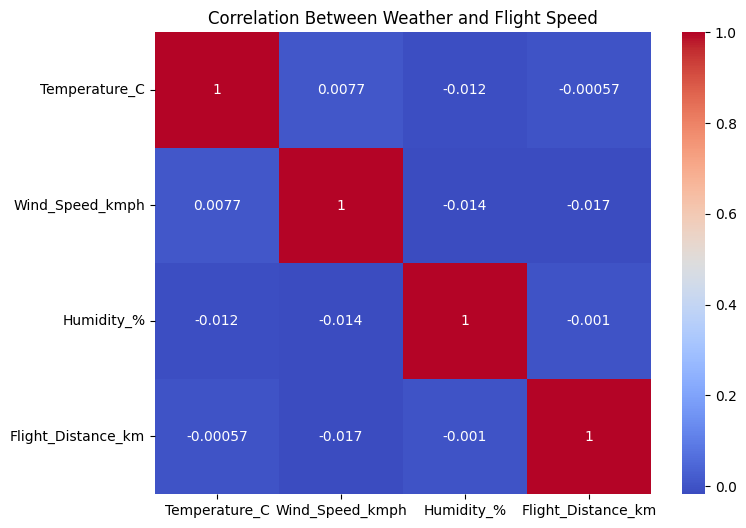

In [84]:
# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(weather_speed_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Between Weather and Flight Speed')
plt.show()

In [85]:
weather_flight_corr = data[['Temperature_C',
                            'Wind_Speed_kmph',
                            'Humidity_%',
                            'Flight_Distance_km',
                            'Average_Speed_kmph']].corr()

print("Correlation between Weather and Flight Performance:")
print(weather_flight_corr[['Flight_Distance_km', 'Average_Speed_kmph']])

# Relationship between weather and nesting success (breeding migrations)
nesting_weather = data[data['Migration_Reason'] == 'Breeding'][['Temperature_C',
                                                                'Wind_Speed_kmph',
                                                                'Humidity_%']].mean()

print("\nAverage Weather Conditions during Breeding (Nesting Success):")
print(nesting_weather)

Correlation between Weather and Flight Performance:
                    Flight_Distance_km  Average_Speed_kmph
Temperature_C                -0.000570           -0.000084
Wind_Speed_kmph              -0.017460           -0.002530
Humidity_%                   -0.001048            0.004506
Flight_Distance_km            1.000000           -0.009805
Average_Speed_kmph           -0.009805            1.000000

Average Weather Conditions during Breeding (Nesting Success):
Temperature_C      12.602340
Wind_Speed_kmph    30.155090
Humidity_%         53.837849
dtype: float64


In [86]:
data.columns

Index(['Species', 'Region', 'Habitat', 'Weather_Condition', 'Migration_Reason',
       'Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude',
       'Flight_Distance_km', 'Flight_Duration_hours', 'Average_Speed_kmph',
       'Max_Altitude_m', 'Min_Altitude_m', 'Temperature_C', 'Wind_Speed_kmph',
       'Humidity_%', 'Pressure_hPa', 'Visibility_km', 'Nesting_Success',
       'Tag_Battery_Level_%', 'Migration_Start_Month', 'Migration_End_Month',
       'Rest_Stops', 'Predator_Sightings', 'Migrated_in_Flock', 'Flock_Size',
       'Food_Supply_Level', 'Tracking_Quality', 'Migration_Interrupted',
       'Interrupted_Reason', 'Migration_Success', 'Recovery_Location_Known',
       'Recovery_Time_days', 'Origin', 'Food_Supply_Num', 'Flock_Size_Band',
       'Flock_Size_Num', 'Flight_Distance_Category', 'Speed_Category',
       'Altitude_Category', 'Temperature_Category', 'Wind_Speed_Category',
       'Visibility_Category', 'Humidity_Category', 'Migration_Success_Num',
       'Fo

## weather Vs migration success 

In [87]:
print(data['Migration_Success'].values)

[nan nan nan ... nan nan nan]


In [88]:
env_factors_corr = data[['Temperature_C',
                         'Wind_Speed_kmph',
                         'Humidity_%',
                         'Max_Altitude_m',
                         'Min_Altitude_m',
                         'Flight_Distance_km',
                         'Migration_Success']].corr()

print("Correlation between Environmental Factors and Migration Success:")
print(env_factors_corr['Migration_Success'])

Correlation between Environmental Factors and Migration Success:
Temperature_C        NaN
Wind_Speed_kmph      NaN
Humidity_%           NaN
Max_Altitude_m       NaN
Min_Altitude_m       NaN
Flight_Distance_km   NaN
Migration_Success    NaN
Name: Migration_Success, dtype: float64


In [89]:
altitude_interruptions_corr = data[['Max_Altitude_m', 'Min_Altitude_m', 'Migration_Interrupted']].corr()
print(altitude_interruptions_corr)

ValueError: could not convert string to float: 'Yes'

In [92]:
#Question: What are the migration patterns for different bird species?
species_migration = data.groupby('Species')[['Flight_Distance_km', 'Average_Speed_kmph', 'Max_Altitude_m']].mean().reset_index()
print(species_migration)


   Species  Flight_Distance_km  Average_Speed_kmph  Max_Altitude_m
0    Crane         2467.412983           49.786909     5444.657081
1    Eagle         2514.805098           49.914116     5535.745442
2    Goose         2496.023130           50.015525     5479.738095
3     Hawk         2512.792589           49.859891     5573.135246
4    Stork         2536.632787           50.031480     5574.164698
5  Swallow         2500.581933           49.987723     5439.527758
6  Warbler         2498.590455           50.075535     5482.704689


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_41760\2972810782.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  species_migration = data.groupby('Species')[['Flight_Distance_km', 'Average_Speed_kmph', 'Max_Altitude_m']].mean().reset_index()


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_41760\3453437582.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=species_migration, x='Species', y='Flight_Distance_km', palette='viridis')


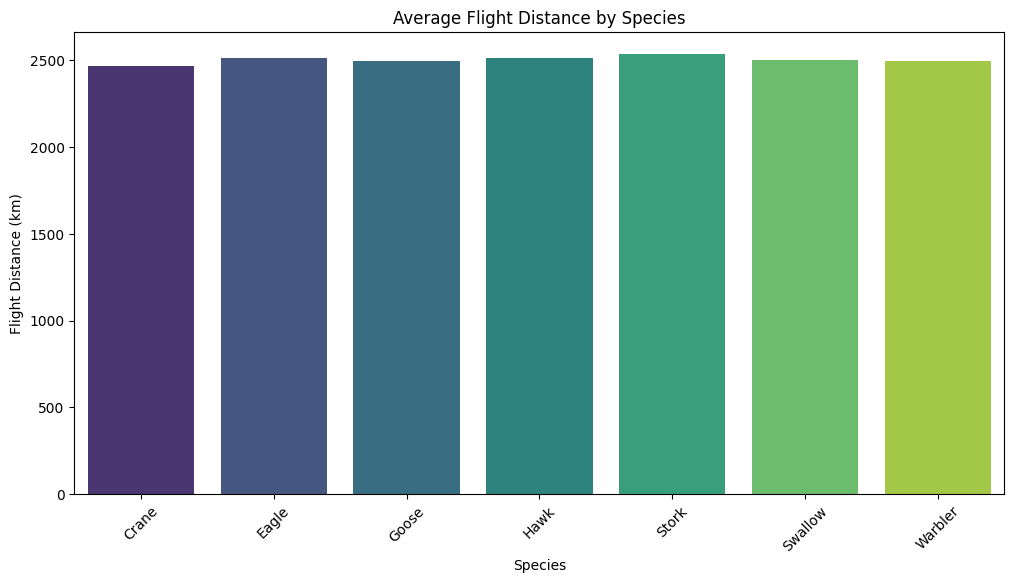

In [93]:
# Visualize migration patterns by species
plt.figure(figsize=(12, 6))
sns.barplot(data=species_migration, x='Species', y='Flight_Distance_km', palette='viridis')
plt.title('Average Flight Distance by Species')
plt.xlabel('Species')
plt.ylabel('Flight Distance (km)')
plt.xticks(rotation=45)
plt.show()

In [94]:
#Question: How does weather impact migration success and interruptions?
weather_success = data.groupby('Weather_Condition')['Migration_Success'].value_counts(normalize=True).unstack()
print(weather_success)

# Visualize migration success by weather condition
weather_success.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Impact of Weather on Migration Success')
plt.xlabel('Weather Condition')
plt.ylabel('Proportion of Migration Success')
plt.legend(title='Migration Success', loc='upper right')
plt.xticks(rotation=45)
plt.show()


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_41760\34807682.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weather_success = data.groupby('Weather_Condition')['Migration_Success'].value_counts(normalize=True).unstack()


Empty DataFrame
Columns: []
Index: []


TypeError: no numeric data to plot

Migration_Interrupted        No       Yes
Weather_Condition                        
Clear                  0.496623  0.503377
Foggy                  0.497191  0.502809
Rainy                  0.498437  0.501563
Stormy                 0.497015  0.502985
Windy                  0.495271  0.504729


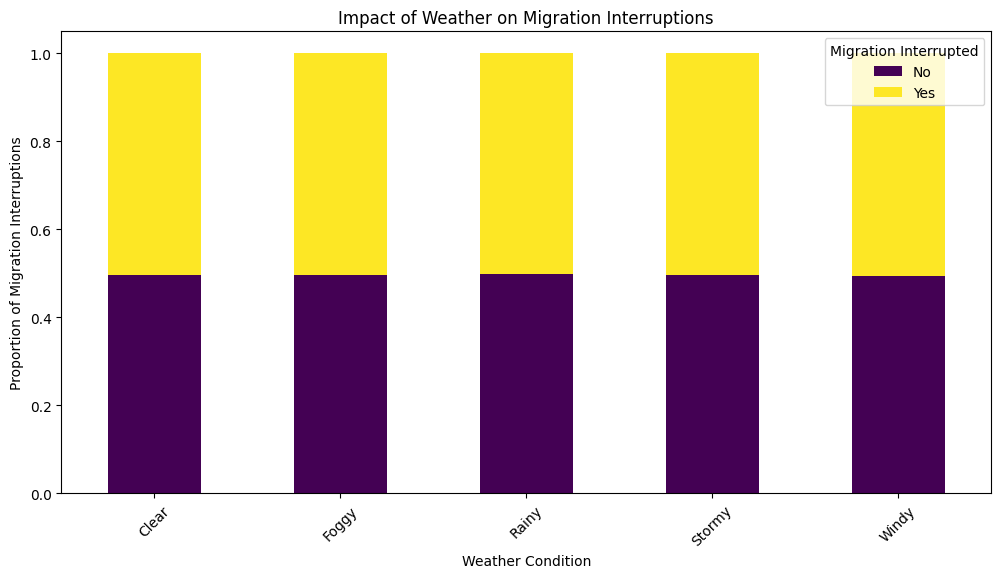

In [ ]:
weather_interruptions = data.groupby('Weather_Condition')['Migration_Interrupted'].value_counts(normalize=True).unstack()
print(weather_interruptions)

# Visualize migration interruptions by weather condition
weather_interruptions.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Impact of Weather on Migration Interruptions')
plt.xlabel('Weather Condition')
plt.ylabel('Proportion of Migration Interruptions')
plt.legend(title='Migration Interrupted', loc='upper right')
plt.xticks(rotation=45)
plt.show()

  Month  Count
0   Mar   1297
1   Jan   1273
2   Nov   1273
3   Oct   1262
4   Feb   1252
5   May   1239
6   Apr   1215
7   Sep   1189


C:\Users\LSGILBE\AppData\Local\Temp\ipykernel_23780\3522240656.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=migration_activity, x='Month', y='Count', palette='viridis')


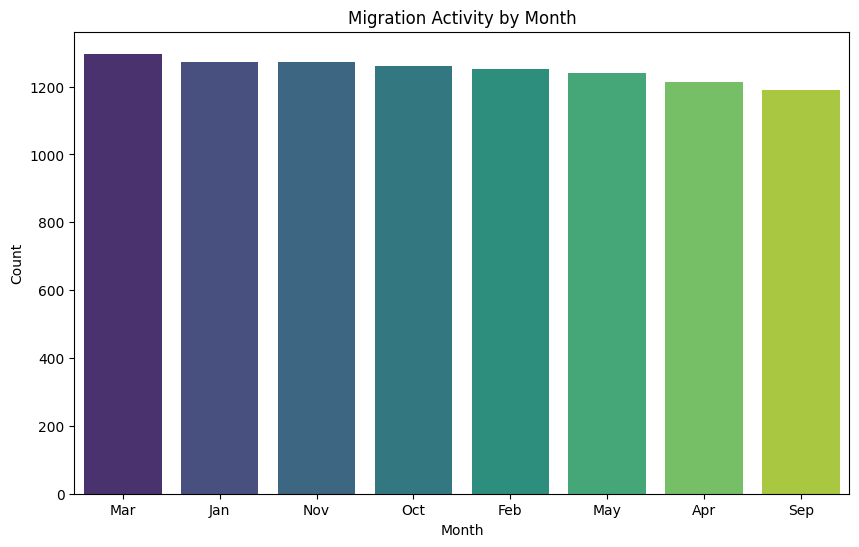

In [ ]:
#Question: Which months see the highest migration activity?
migration_activity = data['Migration_Start_Month'].value_counts().reset_index()
migration_activity.columns = ['Month', 'Count']
print(migration_activity)

# Visualize migration activity by month
plt.figure(figsize=(10, 6))
sns.barplot(data=migration_activity, x='Month', y='Count', palette='viridis')
plt.title('Migration Activity by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

      Start_Latitude  Start_Longitude  End_Latitude  End_Longitude  Count
0         -89.999003       116.802571    -54.380507     151.063906      1
6670       29.153523        24.302352    -78.001126      55.105593      1
6663       28.918140       131.663227     84.862021     164.121040      1
6664       28.928328       -41.482004    -51.356007      16.128116      1
6665       28.975128       -90.409108    -43.965531      76.150803      1


C:\Users\LSGILBE\AppData\Local\Temp\ipykernel_23780\3031518218.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=migration_paths.head(10), x='Count', y='Start_Latitude', palette='viridis')


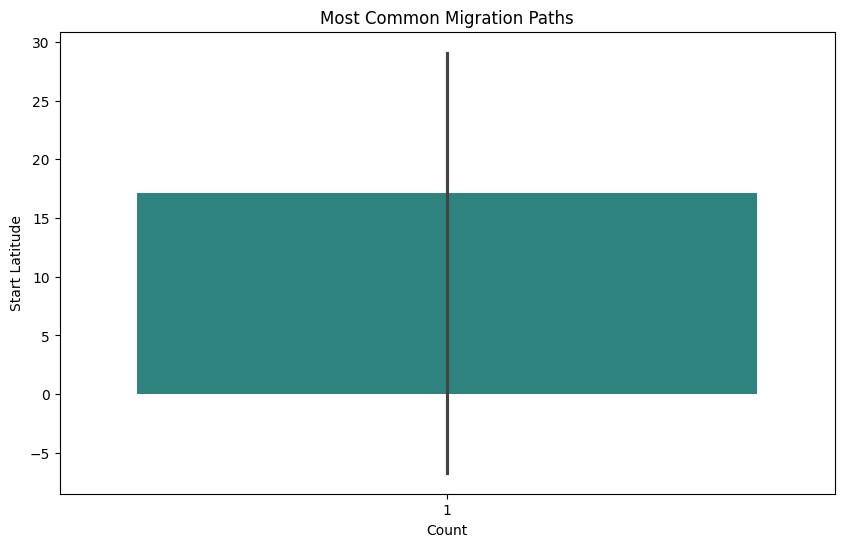

In [ ]:
#Question: What are the most common migration paths for birds?

# Group by start and end locations to find common paths
migration_paths = data.groupby(['Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude']).size().reset_index(name='Count')
migration_paths = migration_paths.sort_values(by='Count', ascending=False)
print(migration_paths.head())

# Visualize the most common migration paths
plt.figure(figsize=(10, 6))
sns.barplot(data=migration_paths.head(10), x='Count', y='Start_Latitude', palette='viridis')
plt.title('Most Common Migration Paths')
plt.xlabel('Count')
plt.ylabel('Start Latitude')
plt.show()

In [ ]:
#Question: Are there correlations between altitude, weather, and migration outcomes?
# Correlation matrix for relevant columns
correlation_matrix = data[['Max_Altitude_m', 'Min_Altitude_m', 'Temperature_C', 'Wind_Speed_kmph', 'Humidity_%', 'Migration_Success']].corr()
print(correlation_matrix)

# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


ValueError: could not convert string to float: 'Failed'

In [95]:
data.dtypes

Species                       category
Region                        category
Habitat                       category
Weather_Condition             category
Migration_Reason              category
Start_Latitude                 float64
Start_Longitude                float64
End_Latitude                   float64
End_Longitude                  float64
Flight_Distance_km             float64
Flight_Duration_hours          float64
Average_Speed_kmph             float64
Max_Altitude_m                   int64
Min_Altitude_m                   int64
Temperature_C                  float64
Wind_Speed_kmph                float64
Humidity_%                       int64
Pressure_hPa                   float64
Visibility_km                  float64
Nesting_Success               category
Tag_Battery_Level_%              int64
Migration_Start_Month         category
Migration_End_Month           category
Rest_Stops                       int64
Predator_Sightings               int64
Migrated_in_Flock        

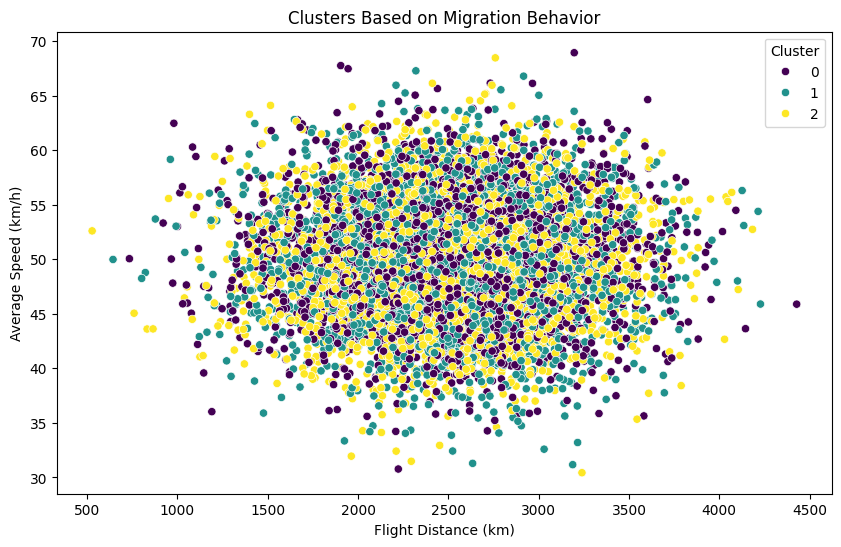

In [96]:
#Can birds be grouped into clusters based on their migration behavior?

from sklearn.cluster import KMeans

# Select features for clustering
clustering_features = ['Flight_Distance_km', 'Average_Speed_kmph', 'Max_Altitude_m']
X = data[clustering_features]

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(X)

# Visualize clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Flight_Distance_km', y='Average_Speed_kmph', hue='Cluster', palette='viridis')
plt.title('Clusters Based on Migration Behavior')
plt.xlabel('Flight Distance (km)')
plt.ylabel('Average Speed (km/h)')
plt.show()

In [97]:
#Question: Can migration success be predicted based on weather, altitude, and speed?
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Prepare data for predictive modeling
features = ['Temperature_C', 'Wind_Speed_kmph', 'Max_Altitude_m', 'Average_Speed_kmph']
target = 'Migration_Success'

# Encode target variable
data[target] = data[target].map({'Yes': 1, 'No': 0})

# Split data into train and test sets
X = data[features]
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Feature importance
feature_importance = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_}).sort_values(by='Importance', ascending=False)
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance for Predicting Migration Success')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

ValueError: Input y contains NaN.

In [ ]:
#Question: Do larger flocks have higher migration success rates?
# Group by flock size and calculate migration success rate
flock_success = data.groupby('Flock_Size')['Migration_Success'].value_counts(normalize=True).unstack()
print(flock_success)

# Visualize migration success by flock size
flock_success.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Migration Success by Flock Size')
plt.xlabel('Flock Size')
plt.ylabel('Proportion of Migration Success')
plt.legend(title='Migration Success', loc='upper right')
plt.show()

Empty DataFrame
Columns: []
Index: []


TypeError: no numeric data to plot

           Region Migration_Start_Month  Flight_Distance_km
0          Africa                   Apr         2441.386243
1          Africa                   Feb         2515.800683
2          Africa                   Jan         2488.484063
3          Africa                   Mar         2456.335607
4          Africa                   May         2477.814866
5          Africa                   Nov         2554.800280
6          Africa                   Oct         2483.768000
7          Africa                   Sep         2513.637354
8            Asia                   Apr         2512.532098
9            Asia                   Feb         2518.757463
10           Asia                   Jan         2543.655087
11           Asia                   Mar         2549.939265
12           Asia                   May         2536.741818
13           Asia                   Nov         2519.378364
14           Asia                   Oct         2510.429189
15           Asia                   Sep 

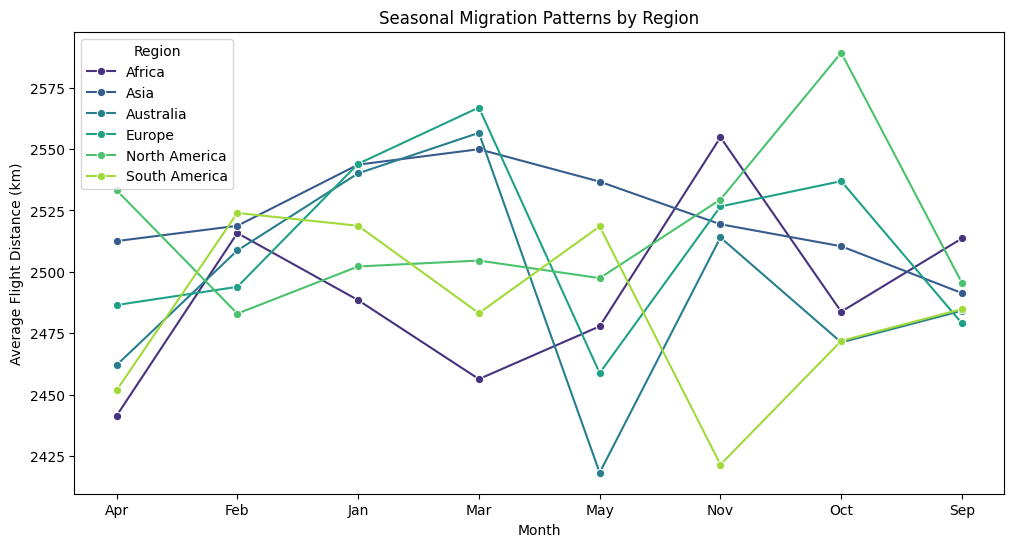

In [ ]:
#Question: How do migration patterns vary across seasons and regions?
# Group by region and start month to calculate average flight distance
regional_seasonal_patterns = data.groupby(['Region', 'Migration_Start_Month'])['Flight_Distance_km'].mean().reset_index()
print(regional_seasonal_patterns)

# Visualize seasonal migration patterns by region
plt.figure(figsize=(12, 6))
sns.lineplot(data=regional_seasonal_patterns, x='Migration_Start_Month', y='Flight_Distance_km', hue='Region', marker='o', palette='viridis')
plt.title('Seasonal Migration Patterns by Region')
plt.xlabel('Month')
plt.ylabel('Average Flight Distance (km)')
plt.show()

In [ ]:
print("Hi")

In [99]:
data.columns

Index(['Species', 'Region', 'Habitat', 'Weather_Condition', 'Migration_Reason',
       'Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude',
       'Flight_Distance_km', 'Flight_Duration_hours', 'Average_Speed_kmph',
       'Max_Altitude_m', 'Min_Altitude_m', 'Temperature_C', 'Wind_Speed_kmph',
       'Humidity_%', 'Pressure_hPa', 'Visibility_km', 'Nesting_Success',
       'Tag_Battery_Level_%', 'Migration_Start_Month', 'Migration_End_Month',
       'Rest_Stops', 'Predator_Sightings', 'Migrated_in_Flock', 'Flock_Size',
       'Food_Supply_Level', 'Tracking_Quality', 'Migration_Interrupted',
       'Interrupted_Reason', 'Migration_Success', 'Recovery_Location_Known',
       'Recovery_Time_days', 'Origin', 'Food_Supply_Num', 'Flock_Size_Band',
       'Flock_Size_Num', 'Flight_Distance_Category', 'Speed_Category',
       'Altitude_Category', 'Temperature_Category', 'Wind_Speed_Category',
       'Visibility_Category', 'Humidity_Category', 'Migration_Success_Num',
       'Fo

In [98]:
import os

file_path = r"C:\Ms_Data_Analytics\Python\ML"
file_name = "Bird_Migration_Analysis.csv"

data.to_csv(os.path.join(file_path, file_name), index=False)

print("File saved successfully at:")
print(os.path.join(file_path, file_name))

File saved successfully at:
C:\Ms_Data_Analytics\Python\ML\Bird_Migration_Analysis.csv


In [3]:
import pandas as pd 
df = pd.read_csv(r"C:\Users\Leo Samuel Gilbert\Bird_migration_ML_prediction\data\processed\Bird_Migration_Analysis.csv")

In [4]:
df.columns

Index(['Species', 'Region', 'Habitat', 'Weather_Condition', 'Migration_Reason',
       'Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude',
       'Flight_Distance_km', 'Flight_Duration_hours', 'Average_Speed_kmph',
       'Max_Altitude_m', 'Min_Altitude_m', 'Temperature_C', 'Wind_Speed_kmph',
       'Humidity_%', 'Pressure_hPa', 'Visibility_km', 'Nesting_Success',
       'Tag_Battery_Level_%', 'Migration_Start_Month', 'Migration_End_Month',
       'Rest_Stops', 'Predator_Sightings', 'Migrated_in_Flock', 'Flock_Size',
       'Food_Supply_Level', 'Tracking_Quality', 'Migration_Interrupted',
       'Interrupted_Reason', 'Migration_Success', 'Recovery_Location_Known',
       'Recovery_Time_days', 'Origin', 'Food_Supply_Num', 'Flock_Size_Band',
       'Flock_Size_Num', 'Flight_Distance_Category', 'Speed_Category',
       'Altitude_Category', 'Temperature_Category', 'Wind_Speed_Category',
       'Visibility_Category', 'Humidity_Category', 'Migration_Success_Num',
       'Fo